In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import statsmodels.api as sm

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv(r'Dados\benchmark_subsample.csv', index_col='Cluster')

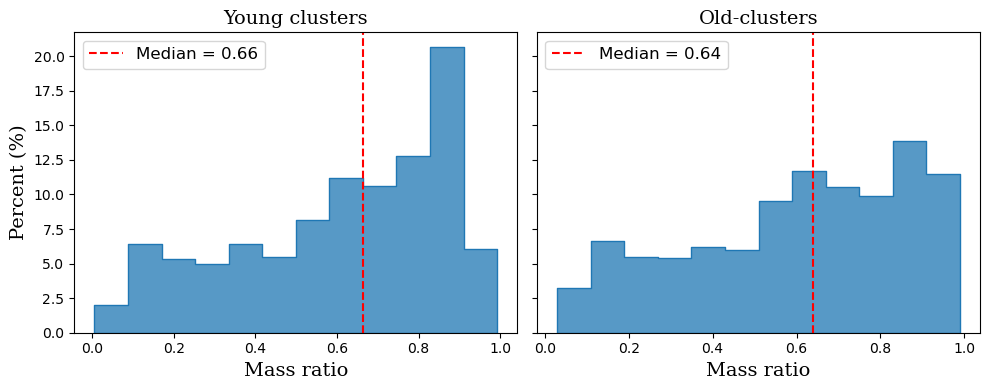

In [3]:
def classificar_idade(age):
    return 'Young clusters' if age < 8 else 'Old-clusters'

aux = data.copy(deep=True)
aux = aux[aux.q > 0]
aux['age_group'] = aux['age'].apply(classificar_idade)

# Cria figura com 2 subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey='row')
age_order = ['Young clusters', 'Old-clusters']

for i, group in enumerate(age_order):
    subset = aux[aux.age_group == group]
    
    sns.histplot(
        data=subset, x='q', element='step', stat='percent', bins=12,
        ax=axs[i], legend=False
    )

    # Mediana de q
    median_q = subset['q'].median()
    axs[i].axvline(median_q, ls='--', c='r', label=f'Median = {round(median_q, 2)}')

    axs[i].set_title(group, fontdict=font)
    axs[i].set_xlabel('Mass ratio', fontdict=font)
    axs[i].legend(fontsize=12)

axs[0].set_ylabel('Percent (%)', fontdict=font)
plt.tight_layout()
# plt.savefig('hist_mass_ratio_mass.png', bbox_inches='tight', dpi=300)
plt.show()


In [4]:
#Compara as distribuições da razão de massa dos dois subconjuntos

young_q = aux[aux.age_group == 'Young clusters']['q']
old_q = aux[aux.age_group == 'Old-clusters']['q']

# Kolmogorov–Smirnov test
ks_stat, ks_p = ks_2samp(young_q, old_q)
print(f"KS test: stat = {ks_stat:.4f}, p = {ks_p:.4f}")
if ks_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')
    
# Mann–Whitney U test    
u_stat, u_p = mannwhitneyu(young_q, old_q, alternative='two-sided')
print(f"Mann–Whitney U test: U = {u_stat:.4f}, p = {u_p:.4f}")

if u_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')

# Anderson–Darling test  
result = anderson_ksamp([young_q, old_q])
print(f"Anderson–Darling test: stat = {result.statistic:.4f}, p = {result.significance_level:.4f}")
if result.significance_level<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')


KS test: stat = 0.0528, p = 0.0000
Distribuições distintas

Mann–Whitney U test: U = 813092259.0000, p = 0.0039
Distribuições distintas

Anderson–Darling test: stat = 144.3620, p = 0.0010
Distribuições distintas



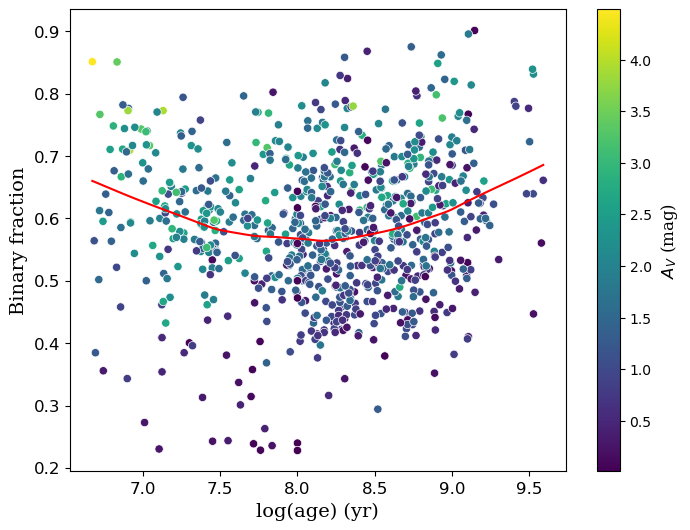

In [5]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='age', y= 'bin_frac', hue = 'Av', palette=palette, legend=False)
lowess = sm.nonparametric.lowess
y_smoothed = lowess(df.bin_frac, df.age,frac=0.4)
plt.plot(y_smoothed[:, 0], y_smoothed[:, 1], color='red', label='LOWESS', )

norm = mpl.colors.Normalize(vmin=df['Av'].min(), vmax=df['Av'].max()) 
sm_ = plt.cm.ScalarMappable(cmap=palette, norm=norm) 
sm_.set_array([]) 
cbar = plt.colorbar(sm_,) 
cbar.set_label('Título do Colorbar', labelpad=2)
cbar.ax.yaxis.set_label_position('left') 
cbar.ax.set_ylabel(r'$A_V$ (mag)', rotation=90, labelpad=-60, va='bottom', fontdict= font_cb )

plt.tick_params(labelsize=labelsize)
plt.xlabel('log(age) (yr)', fontdict=font)
plt.ylabel('Binary fraction', fontdict=font)

#plt.savefig('dist_fb_age.png',bbox_inches='tight', dpi=300)
plt.show()

